<a href="https://colab.research.google.com/github/elvisvaquerano/machine-learning-assignment/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of customers: 200
   annual_income  spending_score  age
0             15              39   19
1             15              81   21
2             16               6   20
3             16              77   23
4             17              40   31


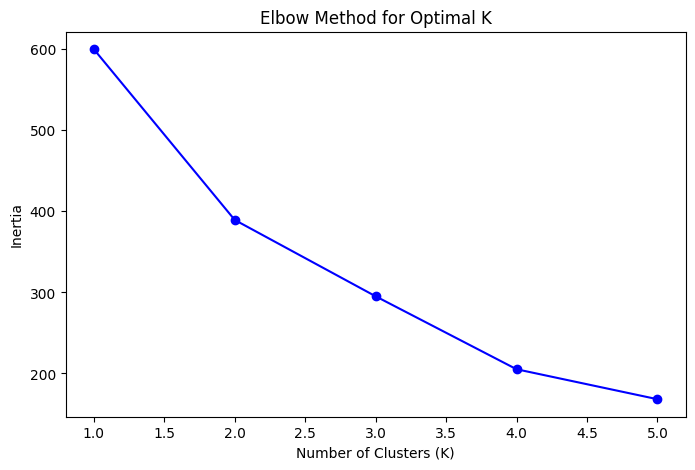

Cluster Characteristics:
         annual_income  spending_score    age
cluster                                      
0                47.71           39.97  53.98
1                86.10           81.53  32.88
2                40.00           60.30  25.44
3                86.50           19.58  39.37

Cluster 0 Strategy:
Low-engagement customers: Use discounts and re-engagement campaigns.

Cluster 1 Strategy:
High-value customers: Offer VIP rewards and exclusive promotions.

Cluster 2 Strategy:
Active shoppers: Offer loyalty rewards and personalized promotions.

Cluster 3 Strategy:
Low-engagement customers: Use discounts and re-engagement campaigns.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
# Load real customer segmentation data
# Data Source: Kaggle - Mall Customer Segmentation Data
# https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

df = pd.read_csv("Mall_Customers.csv")

# Select and rename numerical features to match the starter code
df = df.rename(columns={
    'Annual Income (k$)': 'annual_income',
    'Spending Score (1-100)': 'spending_score',
    'Age': 'age'
})

# Keep only the features needed for clustering
df = df[['annual_income', 'spending_score', 'age']]

# Remove any missing values
df = df.dropna()

print("Number of customers:", len(df))
print(df.head())
# Preprocess data: Select numerical features and scale them
features = ['annual_income', 'spending_score', 'age']
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Determine optimal number of clusters using elbow method
inertia = []
K = range(1, 6)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.savefig('elbow_plot.png')
plt.show()
# Apply K-Means with optimal K (e.g., 3 based on elbow method)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
# Analyze clusters
cluster_summary = df.groupby('cluster')[features].mean().round(2)
print("Cluster Characteristics:")
print(cluster_summary)
# Example of targeted marketing strategies based on real dataset
for cluster in range(optimal_k):
    income = cluster_summary.loc[cluster, 'annual_income']
    spending_score = cluster_summary.loc[cluster, 'spending_score']

    print(f"\nCluster {cluster} Strategy:")

    if income > 70 and spending_score > 60:
        print("High-value customers: Offer VIP rewards and exclusive promotions.")
    elif spending_score > 60:
        print("Active shoppers: Offer loyalty rewards and personalized promotions.")
    elif spending_score < 40:
        print("Low-engagement customers: Use discounts and re-engagement campaigns.")
    else:
        print("Moderate customers: Use targeted promotions to increase engagement.")
# Save cluster assignments to CSV
df.to_csv('customer_segments.csv', index=False)

Conclusion:
This analysis used 200 real customer records from the Mall Customer Segmentation dataset. The numerical features of annual income, spending score, and age were standardized before applying K-Means clustering. The elbow method was used to examine the appropriate number of clusters, and four clusters were selected. The resulting groups showed distinct customer characteristics. For example, Cluster 1 contained high-income, high-spending customers who could be targeted with VIP rewards and exclusive promotions, while Cluster 3 contained high-income customers with relatively low spending scores who could be targeted with re-engagement strategies. Customer segmentation like this can help businesses develop more personalized marketing strategies for different types of customers.